In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_clinical = pd.read_csv(r"C:\Rishit\Projects\Cancer-Analysis\data\raw\tcga\clinical.tsv", 
                          sep='\t', low_memory=False)

print(f"Rows: {df_clinical.shape[0]}")
print(f"Columns: {df_clinical.shape[1]}")
df_clinical.head()

Rows: 5546
Columns: 201


,project.project_id,cases.case_id,cases.consent_type,cases.days_to_consent,cases.days_to_lost_to_followup,cases.disease_type,cases.index_date,cases.lost_to_followup,cases.primary_site,cases.submitter_id,...,treatments.treatment_duration,treatments.treatment_effect,treatments.treatment_effect_indicator,treatments.treatment_frequency,treatments.treatment_id,treatments.treatment_intent_type,treatments.treatment_or_therapy,treatments.treatment_outcome,treatments.treatment_outcome_duration,treatments.treatment_type
0,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,1b884f21-eb24-467f-aba2-208af17070b9,Adjuvant,no,'--,'--,"Radiation Therapy, NOS"
1,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,27868bc3-23c8-5e85-a0e2-314e6cdf9b2a,Adjuvant,yes,Treatment Ongoing,'--,Hormone Therapy
2,TCGA-BRCA,001cef41-ff86-4d3f-a140-a647ac4b10a1,Informed Consent,-34,'--,Ductal and Lobular Neoplasms,Diagnosis,'--,Breast,TCGA-E2-A1IU,...,'--,'--,'--,'--,aedf144c-6b7b-4d76-a3cb-4271aef10f1d,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
3,TCGA-BRCA,0045349c-69d9-4306-a403-c9c1fa836644,Informed Consent,76,'--,Adenomas and Adenocarcinomas,Diagnosis,'--,Breast,TCGA-A1-A0SB,...,'--,'--,'--,'--,0a534cae-de91-5e77-a3e7-b52d46bd3966,First-Line Therapy,yes,'--,'--,"Surgery, NOS"
4,TCGA-BRCA,00807dae-9f4a-4fd1-aac2-82eb11bf2afb,Informed Consent,19,'--,Adnexal and Skin Appendage Neoplasms,Diagnosis,No,Breast,TCGA-A2-A04W,...,'--,'--,'--,'--,024faa94-ec57-4d14-b919-62dcab409958,Adjuvant,yes,Treatment Ongoing,'--,Bisphosphonate Therapy


In [4]:
# Find relevant columns
keywords = ['age', 'race', 'stage', 'vital', 'survival', 'death', 'days', 'gender', 'sex']

for keyword in keywords:
    matching = [col for col in df_clinical.columns if keyword.lower() in col.lower()]
    if matching:
        print(f"\n'{keyword}' columns:")
        for col in matching:
            print(f"  {col}")


'age' columns:
  demographic.age_at_index
  demographic.age_is_obfuscated
  diagnoses.age_at_diagnosis
  diagnoses.ajcc_clinical_stage
  diagnoses.ajcc_pathologic_stage
  diagnoses.ann_arbor_clinical_stage
  diagnoses.ann_arbor_pathologic_stage
  diagnoses.cog_liver_stage
  diagnoses.cog_renal_stage
  diagnoses.enneking_msts_stage
  diagnoses.ensat_pathologic_stage
  diagnoses.esophageal_columnar_dysplasia_degree
  diagnoses.esophageal_columnar_metaplasia_present
  diagnoses.figo_stage
  diagnoses.gastric_esophageal_junction_involvement
  diagnoses.igcccg_stage
  diagnoses.inrg_stage
  diagnoses.inss_stage
  diagnoses.irs_stage
  diagnoses.iss_stage
  diagnoses.masaoka_stage
  diagnoses.uicc_clinical_stage
  diagnoses.uicc_pathologic_stage
  treatments.embolic_agent
  treatments.radiosensitizing_agent
  treatments.therapeutic_agents

'race' columns:
  demographic.race

'stage' columns:
  diagnoses.ajcc_clinical_stage
  diagnoses.ajcc_pathologic_stage
  diagnoses.ann_arbor_clinical_sta

In [7]:
# Convert to numeric, turning any text into NaN
df['days_to_death'] = pd.to_numeric(df['days_to_death'], errors='coerce')
df['days_to_followup'] = pd.to_numeric(df['days_to_followup'], errors='coerce')

# Now create survival columns
df['survival_days'] = df['days_to_death'].fillna(df['days_to_followup'])
df['survival_months'] = df['survival_days'] / 30.44

# Create event column (1 = died, 0 = alive)
df['event'] = df['vital_status'].apply(lambda x: 1 if x == 'Dead' else 0)

print(df.shape)
print(df['race'].value_counts())

(5546, 10)
race
white                               3856
black or african american           1033
not reported                         409
asian                                242
american indian or alaska native       5
'--                                    1
Name: count, dtype: int64


In [8]:
# Remove rows with missing survival data or unknown race
df_clean = df[
    (df['survival_months'].notna()) &
    (df['race'] != 'not reported') &
    (df['race'] != "'--")
].copy()

print(f"Patients after cleaning: {df_clean.shape[0]}")
print(f"\nRace breakdown:")
print(df_clean['race'].value_counts())
print(f"\nVital status breakdown:")
print(df_clean['vital_status'].value_counts())

Patients after cleaning: 4828

Race breakdown:
race
white                               3636
black or african american            957
asian                                230
american indian or alaska native       5
Name: count, dtype: int64

Vital status breakdown:
vital_status
Alive    4013
Dead      815
Name: count, dtype: int64


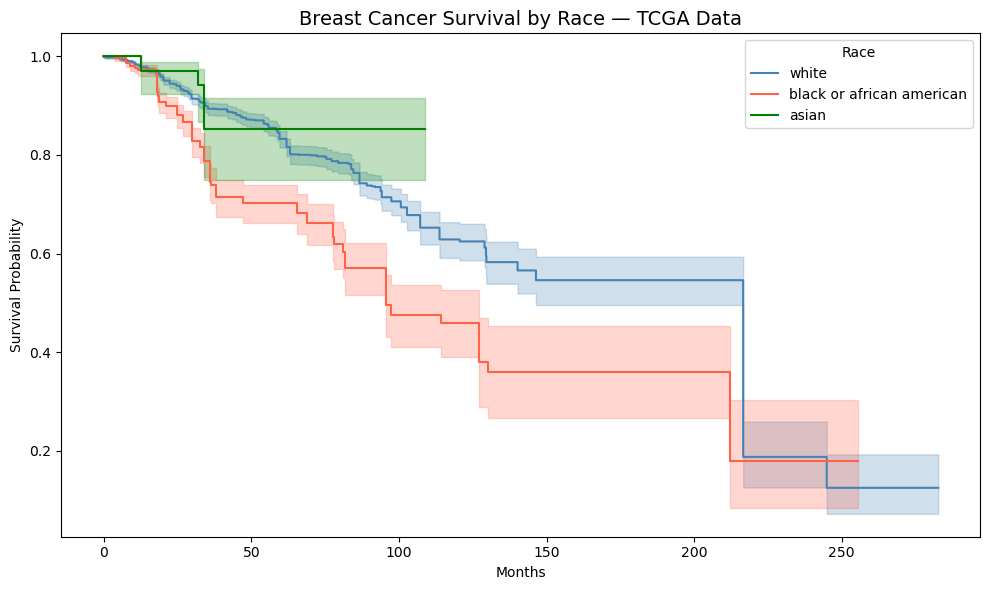

In [10]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(10, 6))

# Only plot races with enough patients
races = ['white', 'black or african american', 'asian']
colors = ['steelblue', 'tomato', 'green']

for race, color in zip(races, colors):
    mask = df_clean['race'] == race
    kmf.fit(df_clean[mask]['survival_months'], 
            event_observed=df_clean[mask]['event'],
            label=race)
    kmf.plot_survival_function(ax=ax, color=color)

ax.set_title('Breast Cancer Survival by Race — TCGA Data', fontsize=14)
ax.set_xlabel('Months')
ax.set_ylabel('Survival Probability')
ax.legend(title='Race')
plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\survival_by_race.png', dpi=150)
plt.show()

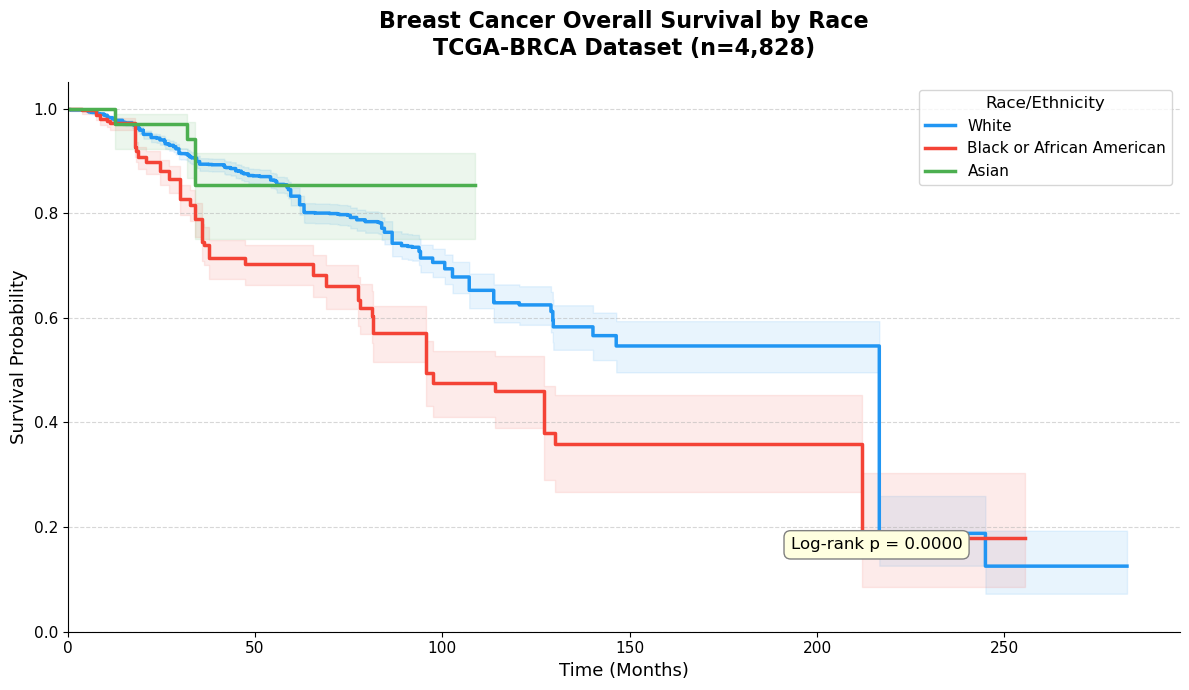


Log-rank test p-value: 0.000000
A p-value < 0.05 means the survival difference between groups is statistically significant.


In [11]:
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Set style
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

kmf = KaplanMeierFitter()
fig, ax = plt.subplots(figsize=(12, 7))

races = ['white', 'black or african american', 'asian']
colors = ['#2196F3', '#F44336', '#4CAF50']
labels = ['White', 'Black or African American', 'Asian']

for race, color, label in zip(races, colors, labels):
    mask = df_clean['race'] == race
    kmf.fit(df_clean[mask]['survival_months'], 
            event_observed=df_clean[mask]['event'],
            label=label)
    kmf.plot_survival_function(ax=ax, color=color, linewidth=2.5, ci_alpha=0.1)

# Add log-rank test p-value
results = multivariate_logrank_test(
    df_clean[df_clean['race'].isin(races)]['survival_months'],
    df_clean[df_clean['race'].isin(races)]['race'],
    df_clean[df_clean['race'].isin(races)]['event']
)
p_value = results.p_value

# Styling
ax.set_title('Breast Cancer Overall Survival by Race\nTCGA-BRCA Dataset (n=4,828)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Time (Months)', fontsize=13)
ax.set_ylabel('Survival Probability', fontsize=13)
ax.set_ylim(0, 1.05)
ax.set_xlim(0)
ax.tick_params(labelsize=11)

# Add p-value annotation
ax.annotate(f'Log-rank p = {p_value:.4f}', 
            xy=(0.65, 0.15), xycoords='axes fraction',
            fontsize=12, 
            bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow', edgecolor='gray'))

# Add gridlines
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.legend(title='Race/Ethnicity', fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\survival_by_race.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nLog-rank test p-value: {p_value:.6f}")
print("A p-value < 0.05 means the survival difference between groups is statistically significant.")

In [13]:
print(df_clean['stage'].value_counts())

stage
Stage IIA     1421
Stage IIB     1164
Stage IIIA     750
Stage IA       332
Stage IIIC     332
Stage I        327
'--            278
Stage IIIB      69
Stage IV        59
Stage IB        33
Stage X         28
Stage II        21
Stage III       14
Name: count, dtype: int64


In [15]:
# Simplify stages into broader categories
def simplify_stage(stage):
    if pd.isna(stage) or stage in ["'--", 'Stage X']:
        return None
    elif 'IV' in stage:
        return 'Stage IV'
    elif 'III' in stage:
        return 'Stage III'
    elif 'II' in stage:
        return 'Stage II'
    elif 'I' in stage:
        return 'Stage I'
    return None

df_clean['stage_simple'] = df_clean['stage'].apply(simplify_stage)

print(df_clean['stage_simple'].value_counts())

stage_simple
Stage II     2606
Stage III    1165
Stage I       692
Stage IV       59
Name: count, dtype: int64


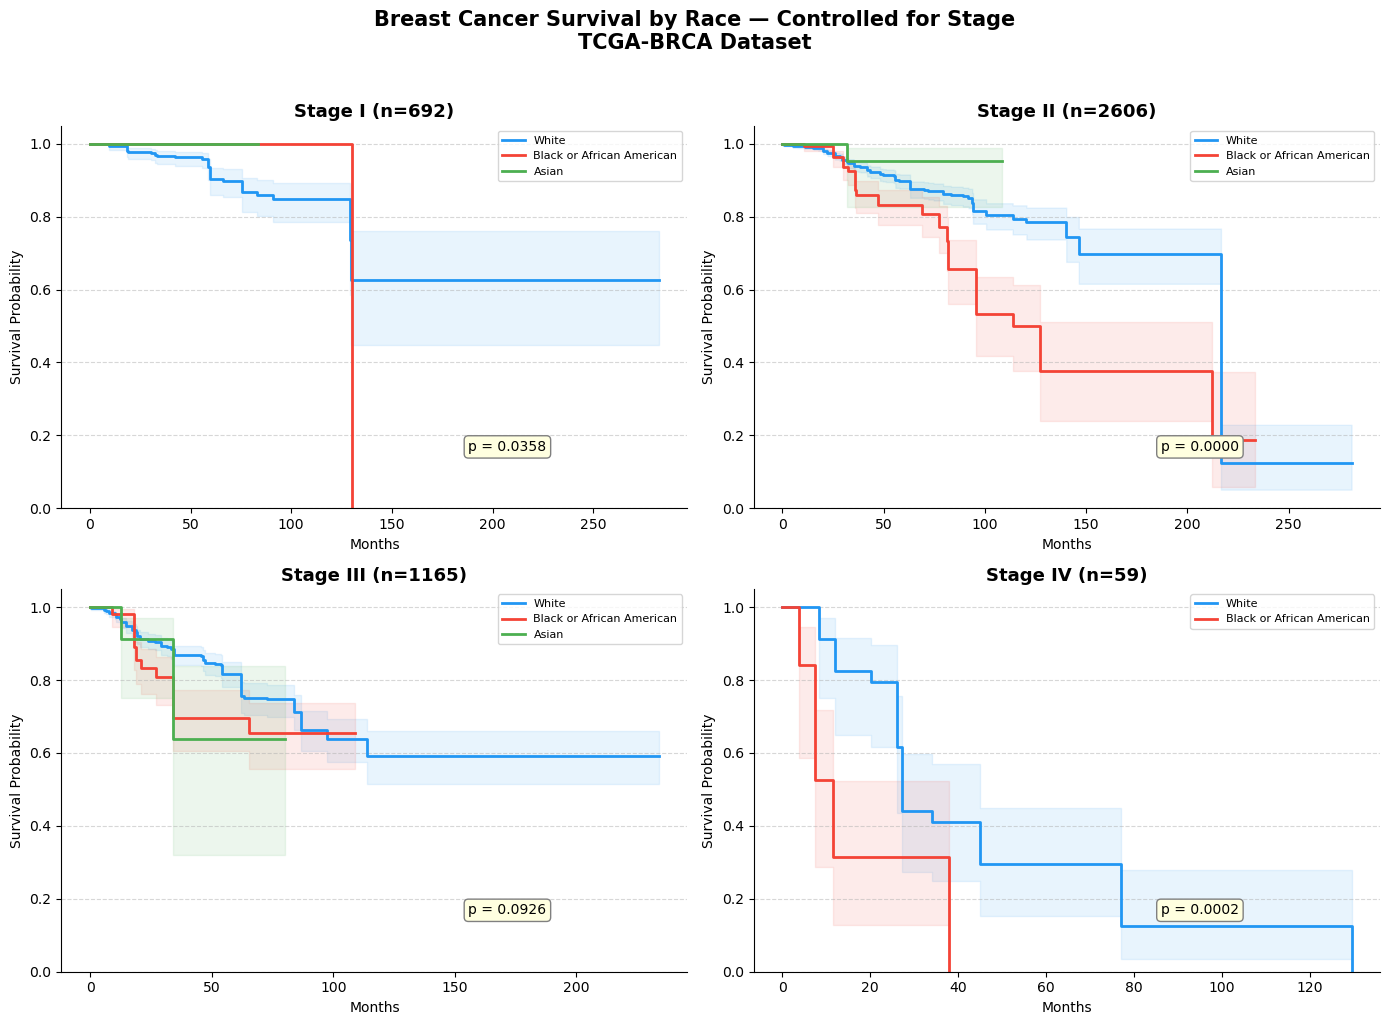

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

stages = ['Stage I', 'Stage II', 'Stage III', 'Stage IV']
races = ['white', 'black or african american', 'asian']
colors = ['#2196F3', '#F44336', '#4CAF50']
labels = ['White', 'Black or African American', 'Asian']

for i, stage in enumerate(stages):
    ax = axes[i]
    stage_df = df_clean[df_clean['stage_simple'] == stage]
    
    for race, color, label in zip(races, colors, labels):
        mask = stage_df['race'] == race
        group = stage_df[mask]
        
        if len(group) < 10:  # skip if too few patients
            continue
            
        kmf = KaplanMeierFitter()
        kmf.fit(group['survival_months'], 
                event_observed=group['event'],
                label=label)
        kmf.plot_survival_function(ax=ax, color=color, linewidth=2, ci_alpha=0.1)
    
    # Log rank test
    stage_races = stage_df[stage_df['race'].isin(races)]
    if len(stage_races['race'].unique()) > 1:
        results = multivariate_logrank_test(
            stage_races['survival_months'],
            stage_races['race'],
            stage_races['event']
        )
        ax.annotate(f'p = {results.p_value:.4f}',
                   xy=(0.65, 0.15), xycoords='axes fraction',
                   fontsize=10,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))
    
    n = len(stage_df)
    ax.set_title(f'{stage} (n={n})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Months', fontsize=10)
    ax.set_ylabel('Survival Probability', fontsize=10)
    ax.set_ylim(0, 1.05)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.legend(fontsize=8)

plt.suptitle('Breast Cancer Survival by Race — Controlled for Stage\nTCGA-BRCA Dataset', 
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(r'C:\Rishit\Projects\Cancer-Analysis\figures\survival_by_race_and_stage.png', 
            dpi=150, bbox_inches='tight')
plt.show()